# Classification Basics


**Before running this notebook, make sure to check `00_environment_setup.md` to see whether you have set the environment correctly.**

In this notebook we'll provide a basic guide to classification using the sklearn library. Make sure to check the `01_classification_metrics.ipynb` notebook for an introduction to classification metrics.



## Outline

1. Recap: What is the classification process?
2. Dataset Description
3. Data splits
4. Binary classification
5. Multi-label classification
6. Multi-class classification

## 1. Recap: What is the classification process?

- We select features to describe our data 
    * We provide a number of features for you, derived from standard signal processing techniques for audio classification.
- We label each datapoint based on what we want the model to learn.
    * You did that during the data annotation phase!
    * Ideally, during the data exploration phase, you gained some insights into which features might be correlated with each other, and which features are more correlated with the labels, and thus could help us predict the labels.
- The features + labels creates our **dataset**
- We pass this to a model and hope it finds some connections between the features and the labels training.

In [113]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from typing import Tuple, List, Dict, Optional, Literal, Union

## 2. Dataset Description

The dataset was **recorded and annotated by you** during the first phases of the project.

### Folder structure

```
MLPC2026_dataset_development.zip
|-- metadata.csv
|-- annotations.csv
\-- audio_features/
    |-- 000001.npz
    |-- 000002.npz
    \-- ...
```

- ```metadata.csv``` contains metadata information about each file.
- ```annotations.csv``` contains the label annotations and their regions (onsets + offsets).
- ```audio_features/``` contains the precomputed audio features.

We also provide an additional zip archive containing the raw audio files, should you wish to use them (not covered in this tutorial). Find more details about the features and metadata in the [Data Exploration Task description](https://moodle.jku.at/pluginfile.php/13827494/mod_resource/content/8/MLPC_2026S___Data_Exploration-1.pdf).


In [114]:
# TODO: MAKE SURE TO CHANGE THE PATH TO THE DATASET HERE!
# Remember that Windows and Linux/Mac handle paths differently.
PATH_TO_DATASET = os.path.join("..", "data", "MLPC2026_dataset_development")

assert os.path.exists(
    PATH_TO_DATASET
), "The dataset folder 'MLPC2026_dataset' does not exist; download the data set and extract its content."
assert os.path.exists(
    os.path.join(PATH_TO_DATASET, "annotations.csv")
), "The file 'MLPC2026_dataset/annotations.csv' does not exist."
assert os.path.exists(
    os.path.join(PATH_TO_DATASET, "metadata.csv")
), "The file 'MLPC2026_dataset/metadata.csv' does not exist."
assert os.path.exists(
    os.path.join(PATH_TO_DATASET, "audio_features")
), "The folder 'MLPC2026_dataset/audio_features' does not exist."

In [115]:
rng = np.random.default_rng(seed=42)

all_audio_features_paths = glob.glob(
    os.path.join(PATH_TO_DATASET, "audio_features", "*.npz")
)
# TODO: Instead of using all files, we will choose just a few,
# otherwise it will take a long time to do all of the experiments
select_subset = 0.2
print(f"Selecting {select_subset*100}% of the dataset")
audio_features_paths = rng.choice(
    all_audio_features_paths,
    size=int(len(all_audio_features_paths) * select_subset),
    replace=False,
).tolist()

Selecting 20.0% of the dataset


As a reminder, here is the information contained in each of the files:

In [116]:
# These are the features computed
# using signal processing techniques
# directly on the audio files.
FEATURE_NAMES = [
    "zcr_mean",
    "zcr_std",
    "zcr_min",
    "zcr_max",
    "melspect_mean",
    "melspect_std",
    "melspect_min",
    "melspect_max",
    "mfcc_mean",
    "mfcc_std",
    "mfcc_min",
    "mfcc_max",
    "mfcc_d_mean",
    "mfcc_d_std",
    "mfcc_d_min",
    "mfcc_d_max",
    "mfcc_d2_mean",
    "mfcc_d2_std",
    "mfcc_d2_min",
    "mfcc_d2_max",
    "flux_mean",
    "flux_std",
    "flux_min",
    "flux_max",
    "flatness_mean",
    "flatness_std",
    "flatness_min",
    "flatness_max",
    "centroid_mean",
    "centroid_std",
    "centroid_min",
    "centroid_max",
    "bandwidth_mean",
    "bandwidth_std",
    "bandwidth_min",
    "bandwidth_max",
    "contrast_mean",
    "contrast_std",
    "contrast_min",
    "contrast_max",
    "rolloff_low_mean",
    "rolloff_low_std",
    "rolloff_low_min",
    "rolloff_low_max",
    "rolloff_high_mean",
    "rolloff_high_std",
    "rolloff_high_min",
    "rolloff_high_max",
    "energy_mean",
    "energy_std",
    "energy_min",
    "energy_max",
    "power_mean",
    "power_std",
    "power_min",
    "power_max",
]

# These are meta data contained in each of the files
METADATA_NAMES = [
    "start_time",
    "end_time",
    "annotations",
    "is_own_recording",
    "class_names",
    "annotator_ids",
    "target_classes",
    "non_target_classes",
    "recording_device",
    "recording_environments",
    "scene_description",
    "device_placement",
]

# Finally, as a reminder, these are the names of our target classes
# which you helped annotate. Thank you everyone for your effort! ;)
CLASSES_NAMES = [
    "bell_ringing",
    "coffee_machine",
    "cutlery_dishes",
    "door_open_close",
    "footsteps",
    "keyboard_typing",
    "keychain",
    "light_switch",
    "microwave",
    "phone_ringing",
    "running_water",
    "toilet_flushing",
    "vacuum_cleaner",
    "wardrobe_drawer_open_close",
    "window_open_close",
]

We then specify a function to load the data. Note that this function supports three modes: "binary", "multiclass" and "multilabel" classification (we learned about them in our previous notebook `01_classification_metrics.ipynb`, so check it out if you need a reminder.)

In [117]:
def get_features_and_targets(
    audio_features: np.ndarray,
    label_type: Literal["binary", "multiclass", "multilabel"] = "multilabel",
) -> Tuple[np.ndarray, Union[np.ndarray, Dict[str, np.ndarray]]]:
    """Load audio features and aggregated target labels from a .npz file.

    Parameters
    ----------
    audio_features : np.ndarray
        .npz file containing audio features and annotations.
    label_type : {"binary", "multiclass", "multilabel"}
        How to encode the targets:
        - "multilabel": binary matrix of shape (T, C), one column per class.
        - "multiclass": integer class index of shape (T, 1), argmax over classes.
        - "binary": dict mapping each class name to a binary array of shape (T, 1).

    Returns
    -------
    x : np.ndarray of shape (T, D)
        Feature matrix with T time frames and D feature dimensions.
    y : np.ndarray of shape (T, C) or (T, 1), or Dict[str, np.ndarray]
        Labels in the format specified by ``label_type``.
    """
    annotations = audio_features["annotations"]
    T, C, _ = annotations.shape

    # Concatenate all features
    x = np.empty(
        (
            T,
            sum(
                audio_features[f].shape[1] if audio_features[f].ndim > 1 else 1
                for f in FEATURE_NAMES
            ),
        )
    )
    col = 0
    for feat_name in FEATURE_NAMES:
        feat = audio_features[feat_name]
        width = feat.shape[1] if feat.ndim > 1 else 1
        x[:, col : col + width] = feat if feat.ndim > 1 else feat[:, None]
        col += width

    # Weighted majority vote — recording creator gets 1.2x weight
    is_own = audio_features["is_own_recording"].astype(bool)   # (A,)
    weights = np.where(is_own, 1.2, 1.0)                       # (A,)
    weighted_votes = np.tensordot(annotations, weights, axes=(2, 0)) / weights.sum()  # (T, C)

    if label_type == "multilabel":
        y = (weighted_votes > 0.5).astype(int)
    elif label_type == "multiclass":
        y = np.argmax(weighted_votes, axis=1).astype(int).reshape(T, 1)
    else:  # "binary"
        y = make_binary_targets((weighted_votes > 0.5).astype(int))

    return x, y


def make_binary_targets(Y: np.ndarray) -> Dict[str, np.ndarray]:
    """Convert a multilabel indicator matrix into per-class binary arrays.

    Parameters
    ----------
    Y : np.ndarray of shape (N, C)
        Binary multilabel matrix with N frames and C classes.

    Returns
    -------
    Y_binary : dict of {str: np.ndarray}
        Dictionary mapping each class name in ``CLASSES_NAMES`` to a binary
        array of shape (N, 1).
    """
    return {
        class_name: Y[:, idx].reshape(-1, 1).astype(int)
        for idx, class_name in enumerate(CLASSES_NAMES)
    }

In [118]:
def read_files(
    file_list: List[str],
    label_type: Literal["binary", "multiclass", "multilabel"] = "multilabel",
) -> Tuple[np.ndarray, Union[np.ndarray, Dict[str, np.ndarray]]]:
    """Load and stack features and labels from a list of .npz files.

    Parameters
    ----------
    file_list : list of str
        Paths to .npz audio feature files to load.
    label_type : {"binary", "multiclass", "multilabel"}
        Passed through to ``get_features_and_targets``; controls the format of
        the returned labels.

    Returns
    -------
    X : np.ndarray of shape (N, D)
        Stacked feature matrix across all files.
    Y : np.ndarray of shape (N, C) or (N, 1), or Dict[str, np.ndarray]
        Stacked labels in the format specified by ``label_type``.
    creator_id : list of creator_ids for each sample
    """
    if label_type not in ("binary", "multiclass", "multilabel"):
        raise ValueError(
            f"`label_type` must be 'binary', 'multiclass', or 'multilabel', got {label_type!r}"
        )
    X = []
    Y = []
    creator_id = []

    for filename in file_list:
        audio_features = dict(np.load(filename, allow_pickle=True))
        
        x, y = get_features_and_targets(audio_features, label_type=label_type)
        X.append(x)
        Y.append(y)

        annotator_ids = audio_features["annotator_ids"]
        mask = audio_features["is_own_recording"]
        creator = annotator_ids[mask]
        creator_id.append(creator)

    #X = np.vstack(X)

    if label_type == "binary":
        return X, {cls: [y[cls] for y in Y] for cls in CLASSES_NAMES}, creator_id
    else:
        return X, np.vstack(Y), creator_id

### Task 0: Baseline Classifier

In [119]:
# solution
class BaselineClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self):
        self.majority_class = None

    def fit(self, x_train: np.ndarray, y_train: np.ndarray) -> None:
        """Fit the classifier by finding the majority class.

        Parameters
        ----------
        x_train : np.ndarray of shape (N, D)
            Feature matrix with N samples and D dimensions. Not used directly,
            included for API consistency.
        y_train : np.ndarray of shape (N,)
            Binary labels (0 or 1) for each training sample.
        """
        self.classes_ = np.unique(y_train)
        self.majority_class = 1 if sum(y_train) > len(y_train) / 2 else 0

    def predict(self, x: np.ndarray) -> np.ndarray:
        """Predict binary labels for each sample.

        Parameters
        ----------
        x : np.ndarray of shape (N, D)
            Feature matrix with N samples and D dimensions.

        Returns
        -------
        predictions : np.ndarray of shape (N,)
            Predicted binary labels (all equal to the majority class).
        """
        predictions = np.zeros(x.shape[0]) + self.majority_class
        return predictions

Let's use our baseline classifier to predict whether a sound is a bell ringing or not:

In [120]:
X_train, Y_train, creator_ids = read_files(audio_features_paths, label_type="binary")
bell_x = np.vstack(X_train)
bell_y = np.vstack(Y_train["bell_ringing"]) # fixed for modified read_files output

Accuracy: 0.984247
Precision: 0.000000
Recall: 0.000000
F1: 0.000000


/opt/anaconda3/envs/mlpc2026/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


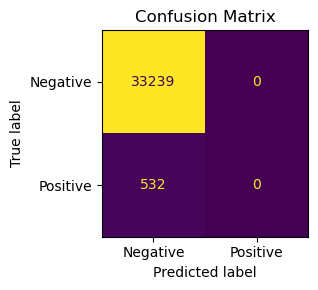

In [121]:
baseline = BaselineClassifier()
baseline.fit(bell_x, bell_y)

y_train_pred = baseline.predict(bell_x)

y_true = bell_y.ravel()
y_pred = y_train_pred.ravel()

acc = np.mean(y_pred == y_true)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy: {acc:2f}")
print(f"Precision: {prec:2f}")
print(f"Recall: {rec:2f}")
print(f"F1: {f1:2f}")

fig, ax = plt.subplots(figsize=(5,3))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Negative", "Positive"],
    colorbar=False,
    ax=ax,
)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

The resulting accuracy is very high. But does this mean our baseline classifier is good?

Actually not. The high accuracy is a result of label imbalance. Can you already think of better ways to estimate the model performance? (**Hint**: check `01_classification_metrics.ipynb`)

## 3. Data Split

### Splits per class

In [122]:
# Idea is to split the dataset differently depending on the class, to keep class distribution equal while avoiding data leakage through having
# different timesteps from the same sample in both train(cross val) and test. We also want to avoid dataset bias through using the same creator in the train and never in the test set.

# first get all the data. start with less from the data and then go more once the thing is running
all_audio_features_paths = glob.glob(
    os.path.join(PATH_TO_DATASET, "audio_features", "*.npz")
)

select_subset = 1

audio_features_paths = rng.choice(
    all_audio_features_paths,
    size=int(len(all_audio_features_paths) * select_subset),
    replace=False,
).tolist()
print(len(audio_features_paths))

3656


In [123]:
X, Y, creator_ids = read_files(audio_features_paths, label_type="binary")

label_dict = {}
for cls in CLASSES_NAMES:
    cls_y_train = Y[cls]

    label_list = []
    for i in range(len(cls_y_train)):
        label = int(cls_y_train[i].any())
        label_list.append(label)

    label_dict[cls] = label_list
    
    print(f"Class {cls} is existent in {np.sum(label_list) / len(label_list):.2%} of the dataset")

Class bell_ringing is existent in 7.36% of the dataset
Class coffee_machine is existent in 5.55% of the dataset
Class cutlery_dishes is existent in 20.98% of the dataset
Class door_open_close is existent in 29.98% of the dataset
Class footsteps is existent in 47.16% of the dataset
Class keyboard_typing is existent in 19.61% of the dataset
Class keychain is existent in 18.24% of the dataset
Class light_switch is existent in 7.47% of the dataset
Class microwave is existent in 10.50% of the dataset
Class phone_ringing is existent in 20.62% of the dataset
Class running_water is existent in 26.86% of the dataset
Class toilet_flushing is existent in 10.97% of the dataset
Class vacuum_cleaner is existent in 8.78% of the dataset
Class wardrobe_drawer_open_close is existent in 14.82% of the dataset
Class window_open_close is existent in 12.50% of the dataset


In [124]:
# I need to fix  creator ids. it has NaNs. We introduce the Nan creator id -1 which is its own group
def clean_creator(creator_ids: list):
    clean_creator_ids = []

    for c in creator_ids:
        c_arr = np.asarray(c)

        if c_arr.size == 0:
            val = -1
        else:
            val = c_arr.item()

        clean_creator_ids.append(val)
    return clean_creator_ids

In [125]:
# SECOND APPROACH: only group recordings by creators, no stratification. Check class distributions after the split manually and adjust seed if they are skewed too much.
clean_creator_ids = clean_creator(creator_ids)

unique_creators = list(set(clean_creator_ids))
train_creators, test_creators = train_test_split(
    unique_creators,
    test_size=0.2,
    random_state=6, # empirically found to give a good class distribution in train and test set
)

# for each file, check which split the creator belongs to
train_file_indices = []
test_file_indices = []

for file_idx, creator in enumerate(clean_creator_ids):
    if creator in train_creators:
        train_file_indices.append(file_idx)
    else:
        test_file_indices.append(file_idx)

train_files_creator = [audio_features_paths[i] for i in train_file_indices]
test_files_creator  = [audio_features_paths[i] for i in test_file_indices]

print(f"Creators  — train: {len(train_creators)}, test: {len(test_creators)}")
print(f"Recordings — train: {len(train_files_creator)}, test: {len(test_files_creator)}")

# verify class distribution
print(f"\n{'Class':<30} {'Overall':>8} {'Train':>8} {'Test':>8}")
print("-" * 58)
for cls in CLASSES_NAMES:
    overall = np.mean(label_dict[cls])
    train   = np.mean([label_dict[cls][i] for i in train_file_indices])
    test    = np.mean([label_dict[cls][i] for i in test_file_indices])
    print(f"{cls:<30} {overall:>8.2%} {train:>8.2%} {test:>8.2%}")

Creators  — train: 286, test: 72
Recordings — train: 2586, test: 1070

Class                           Overall    Train     Test
----------------------------------------------------------
bell_ringing                      7.36%    7.27%    7.57%
coffee_machine                    5.55%    5.80%    4.95%
cutlery_dishes                   20.98%   21.62%   19.44%
door_open_close                  29.98%   29.74%   30.56%
footsteps                        47.16%   47.14%   47.20%
keyboard_typing                  19.61%   19.45%   20.00%
keychain                         18.24%   18.64%   17.29%
light_switch                      7.47%    7.12%    8.32%
microwave                        10.50%   10.83%    9.72%
phone_ringing                    20.62%   20.65%   20.56%
running_water                    26.86%   26.68%   27.29%
toilet_flushing                  10.97%   11.14%   10.56%
vacuum_cleaner                    8.78%    8.39%    9.72%
wardrobe_drawer_open_close       14.82%   14.97%   14.49%


In [126]:
rows = []
for cls in CLASSES_NAMES:
    rows.append({
        "Class": cls,
        "Overall": np.mean(label_dict[cls]),
        "Train": np.mean([label_dict[cls][i] for i in train_file_indices]),
        "Test": np.mean([label_dict[cls][i] for i in test_file_indices]),
    })

df = pd.DataFrame(rows)

print(df.to_latex(index=False, float_format="%.2f"))

\begin{tabular}{lrrr}
\toprule
Class & Overall & Train & Test \\
\midrule
bell_ringing & 0.07 & 0.07 & 0.08 \\
coffee_machine & 0.06 & 0.06 & 0.05 \\
cutlery_dishes & 0.21 & 0.22 & 0.19 \\
door_open_close & 0.30 & 0.30 & 0.31 \\
footsteps & 0.47 & 0.47 & 0.47 \\
keyboard_typing & 0.20 & 0.19 & 0.20 \\
keychain & 0.18 & 0.19 & 0.17 \\
light_switch & 0.07 & 0.07 & 0.08 \\
microwave & 0.11 & 0.11 & 0.10 \\
phone_ringing & 0.21 & 0.21 & 0.21 \\
running_water & 0.27 & 0.27 & 0.27 \\
toilet_flushing & 0.11 & 0.11 & 0.11 \\
vacuum_cleaner & 0.09 & 0.08 & 0.10 \\
wardrobe_drawer_open_close & 0.15 & 0.15 & 0.14 \\
window_open_close & 0.12 & 0.12 & 0.13 \\
\bottomrule
\end{tabular}



### Preprocessing


In [127]:
# Feature Selection, Normalisation, Feature Engineering
# Feature Selection. Choose the same as for t-SNE in previous task. Taken by visually analysing the correlation matrix. I would suggest to trying some of this
feature_select = [
    "zcr_mean", "zcr_std", "zcr_min", "zcr_max",
    "mfcc_mean", "mfcc_std", "mfcc_min", "mfcc_max",
    "mfcc_d_mean", "mfcc_d_std", "mfcc_d_min", "mfcc_d_max",
    "mfcc_d2_mean", "mfcc_d2_std", "mfcc_d2_min", "mfcc_d2_max",
    "contrast_mean", "contrast_std", "contrast_min", "contrast_max",
    "power_mean", "power_std", "power_min", "power_max"
]
all_feature_names = FEATURE_NAMES + METADATA_NAMES
# Let ChatGPT make a mapping to find the important features in the stacked form
FEATURE_MAP = {
    # ZCR (1 dim × 4 stats)
    "zcr_mean": slice(0, 1),
    "zcr_std": slice(1, 2),
    "zcr_min": slice(2, 3),
    "zcr_max": slice(3, 4),

    # melspect (128 × 4 = 512)
    "melspect_mean": slice(4, 132),
    "melspect_std": slice(132, 260),
    "melspect_min": slice(260, 388),
    "melspect_max": slice(388, 516),

    # mfcc (32 × 4 = 128)
    "mfcc_mean": slice(516, 548),
    "mfcc_std": slice(548, 580),
    "mfcc_min": slice(580, 612),
    "mfcc_max": slice(612, 644),

    # mfcc_d
    "mfcc_d_mean": slice(644, 676),
    "mfcc_d_std": slice(676, 708),
    "mfcc_d_min": slice(708, 740),
    "mfcc_d_max": slice(740, 772),

    # mfcc_d2
    "mfcc_d2_mean": slice(772, 804),
    "mfcc_d2_std": slice(804, 836),
    "mfcc_d2_min": slice(836, 868),
    "mfcc_d2_max": slice(868, 900),

    # flux (1 × 4)
    "flux_mean": slice(900, 901),
    "flux_std": slice(901, 902),
    "flux_min": slice(902, 903),
    "flux_max": slice(903, 904),

    # flatness
    "flatness_mean": slice(904, 905),
    "flatness_std": slice(905, 906),
    "flatness_min": slice(906, 907),
    "flatness_max": slice(907, 908),

    # centroid
    "centroid_mean": slice(908, 909),
    "centroid_std": slice(909, 910),
    "centroid_min": slice(910, 911),
    "centroid_max": slice(911, 912),

    # bandwidth
    "bandwidth_mean": slice(912, 913),
    "bandwidth_std": slice(913, 914),
    "bandwidth_min": slice(914, 915),
    "bandwidth_max": slice(915, 916),

    # contrast (7 × 4 = 28)
    "contrast_mean": slice(916, 923),
    "contrast_std": slice(923, 930),
    "contrast_min": slice(930, 937),
    "contrast_max": slice(937, 944),

    # rolloff_low
    "rolloff_low_mean": slice(944, 945),
    "rolloff_low_std": slice(945, 946),
    "rolloff_low_min": slice(946, 947),
    "rolloff_low_max": slice(947, 948),

    # rolloff_high
    "rolloff_high_mean": slice(948, 949),
    "rolloff_high_std": slice(949, 950),
    "rolloff_high_min": slice(950, 951),
    "rolloff_high_max": slice(951, 952),

    # energy
    "energy_mean": slice(952, 953),
    "energy_std": slice(953, 954),
    "energy_min": slice(954, 955),
    "energy_max": slice(955, 956),

    # power
    "power_mean": slice(956, 957),
    "power_std": slice(957, 958),
    "power_min": slice(958, 959),
    "power_max": slice(959, 960),
}

total_dims = sum(
    FEATURE_MAP[f].stop - FEATURE_MAP[f].start
    for f in feature_select
)
print(f"Selected dimensions: {total_dims}")

Selected dimensions: 420


In [128]:
X_train_pre, Y_train_pre, creator_ids_train = read_files(train_files_creator, label_type="binary")
X_test_pre, Y_test, _ = read_files(test_files_creator, label_type="binary")

In [129]:
# Split train set into folds.
clean_creator_train = clean_creator(creator_ids_train)
groups = np.array(clean_creator_train)

from sklearn.model_selection import GroupKFold

group_kfold = GroupKFold(n_splits=5, shuffle=True, random_state=6)

In [130]:
# Train_X in 5 folds. Use any class for Y here. its ignored anyway in groupkfold
from sklearn.preprocessing import StandardScaler

X_train = {}
X_val = {}
Y_train = {}
Y_val = {}

for fold, (train_idx, val_idx) in enumerate(group_kfold.split(X_train_pre, Y_train_pre["footsteps"], groups)):

    # X first. subset by indices
    X_process_train = [X_train_pre[i] for i in train_idx]
    X_process_val = [X_train_pre[i] for i in val_idx]
    
    # stack
    X_process_train = np.vstack(X_process_train)
    X_process_val = np.vstack(X_process_val)

    # feature select
    X_selected_train = []
    X_selected_val = []
    for feature in feature_select:
        slc = FEATURE_MAP[feature]
        X_selected_train.append(X_process_train[:, slc])
        X_selected_val.append(X_process_val[:, slc])

    # stack em back
    X_selected_train = np.hstack(X_selected_train)
    X_selected_val = np.hstack(X_selected_val)

    # Normalise
    scaler = StandardScaler()
    X_selected_train = scaler.fit_transform(X_selected_train)
    X_selected_val = scaler.transform(X_selected_val)

    # At this point one can do feature engineering with appropriate heuristic and or expert knowledge

    # Put into dict
    X_train[f"split {fold}"] = X_selected_train
    X_val[f"split {fold}"] = X_selected_val

    # Now Y
    Y_train[f"split {fold}"] = {}
    Y_val[f"split {fold}"] = {}

    # Stack frame-level labels per class for this fold (Y_train_pre[cls] is list of per-file timestep arrays -> subset by file indices first, then vstack to frames)
    for cls in CLASSES_NAMES:
        Y_train[f"split {fold}"][cls] = np.vstack([Y_train_pre[cls][i] for i in train_idx])
        Y_val[f"split {fold}"][cls] = np.vstack([Y_train_pre[cls][i] for i in val_idx])

# Same with test. Make a full train set too to fit a scaler.
X_stacked__full_train = np.vstack(X_train_pre)
X_stacked_test = np.vstack(X_test_pre)

X_selected_full_train = []
X_selected_test = []
for feature in feature_select:
    slc = FEATURE_MAP[feature]
    X_selected_full_train.append(X_stacked__full_train[:, slc])
    X_selected_test.append(X_stacked_test[:, slc])

X_train_full = np.hstack(X_selected_full_train)
X_test = np.hstack(X_selected_test)

# Normalise all of the data.

scaler = StandardScaler()

X_train_full = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test)

In [131]:
print(f"\n{'Fold':<6} {'Class':<30} {'Train':>8} {'Val':>8}")
print("-" * 70)

for fold in X_train.keys():
    diffs = []
    for cls in CLASSES_NAMES:
        y_train = Y_train[fold][cls]
        y_val   = Y_val[fold][cls]

        train   = y_train.mean()
        val     = y_val.mean()

        diffs.append(train - val)

        print(f"{fold:<6} {cls:<30} {train:>8.2%} {val:>8.2%}")
    print("\n")

    diffs = np.array(diffs)
    std_diff = np.std(diffs)
    
    print(f"{fold:<6} std: {std_diff:>15.4f}")
    print("\n")


Fold   Class                             Train      Val
----------------------------------------------------------------------
split 0 bell_ringing                      1.36%    1.59%
split 0 coffee_machine                    4.14%    4.35%
split 0 cutlery_dishes                    6.65%    7.24%
split 0 door_open_close                   4.01%    4.23%
split 0 footsteps                        13.36%   13.52%
split 0 keyboard_typing                   9.56%    9.98%
split 0 keychain                          5.27%    5.16%
split 0 light_switch                      0.41%    0.40%
split 0 microwave                         8.04%    7.55%
split 0 phone_ringing                     6.70%    7.00%
split 0 running_water                    13.41%   12.47%
split 0 toilet_flushing                   3.40%    3.35%
split 0 vacuum_cleaner                    6.09%    7.38%
split 0 wardrobe_drawer_open_close        2.19%    2.28%
split 0 window_open_close                 1.48%    1.29%


split 0 std:   

## Performance Metrics

| Metric                   | Description                                                 | When It's Useful                                                       |
| ------------------------ | ----------------------------------------------------------- | ---------------------------------------------------------------------- |
| **Accuracy**             | % of correct predictions `(TP + TN) / Total`                | Simple, but **misleading with imbalanced data**                        |
| **Precision**            | How many predicted positives were correct: `TP / (TP + FP)` | Important when **false positives** are costly (e.g., spam filters)     |
| **Recall (Sensitivity)** | How many actual positives were caught: `TP / (TP + FN)`     | Critical when **false negatives** are costly (e.g., medical diagnosis) |
| **F1 Score**             | Harmonic mean of precision and recall                       | Good **balance** when classes are imbalanced                           |
| **ROC AUC**              | Measures ranking ability over all thresholds                | Good for **probabilistic models**; not sensitive to threshold          |
| **PR AUC**               | Area under Precision-Recall curve                           | Better than ROC AUC for **imbalanced data**                            |


### Performance on Baseline Classifier

In [132]:
# EVALUATION METRIC: Macro averaged F1 Score, balances precision and recall, good for imbalanced datasets. Ensures that both false positives and false negatives are considered, all classes are treated equally.

# Baseline: per class, always predict majority class
baseline_f1_per_class = {}

for fold in X_train.keys():
    for cls in CLASSES_NAMES:
        clf = BaselineClassifier()
        clf.fit(X_train[fold], Y_train[fold][cls].ravel())
        y_pred = clf.predict(X_val[fold])
        baseline_f1_per_class[cls] = f1_score(Y_val[fold][cls].ravel(), y_pred, average="binary", zero_division=0) # .ravel: flatten to get 1D array of shape (N,)

macro_f1_baseline = np.mean(list(baseline_f1_per_class.values()))

print(f"{'Class':<30} {'F1':>6}")
print("-" * 38)
for cls, score in baseline_f1_per_class.items():
    print(f"{cls:<30} {score:>6.4f}")
print("-" * 38)
print(f"{'Macro-Avg F1':<30} {macro_f1_baseline:>6.4f}")


Class                              F1
--------------------------------------
bell_ringing                   0.0000
coffee_machine                 0.0000
cutlery_dishes                 0.0000
door_open_close                0.0000
footsteps                      0.0000
keyboard_typing                0.0000
keychain                       0.0000
light_switch                   0.0000
microwave                      0.0000
phone_ringing                  0.0000
running_water                  0.0000
toilet_flushing                0.0000
vacuum_cleaner                 0.0000
wardrobe_drawer_open_close     0.0000
window_open_close              0.0000
--------------------------------------
Macro-Avg F1                   0.0000


As expected, the the baseline always predicts "negative" for every frame, so it never produces a true positive for any sound event, making both precision and recall for the positive class zero and therefore F1 = 0.

## 4. Binary Classification

Now we can move on to training classifiers. Let's start be training a very simple Decision Tree.
A **Decision Tree** is a model that splits data by asking feature-based questions, forming a tree structure.  

In [133]:
X_train, Y_train = read_files(train_files, label_type="binary")
X_test, Y_test = read_files(test_files, label_type="binary")
X_val, Y_val = read_files(validation_files, label_type="binary")

print(len(X_train))
# subsampling the training data to reduce run time
sample_size = 5000
indices = np.random.choice(len(X_train), size=sample_size, replace=False)

X_train = X_train[indices]
for c in CLASSES_NAMES:
    Y_train[c] = Y_train[c][indices]


bell_x_train, bell_y_train = X_train, Y_train["bell_ringing"]
bell_x_test, bell_y_test = X_test, Y_test["bell_ringing"]
bell_x_val, bell_y_val = X_val, Y_val["bell_ringing"]

NameError: name 'train_files' is not defined

In [ ]:
# Define the model
dt = DecisionTreeClassifier(random_state=42)

The DT classifier has several patameters we can experiment with. Let's pick a few to explore

In [ ]:
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
}
best_score = 0
best_params = None
best_model = None

In [ ]:
import numpy as np

max_depths = param_grid["max_depth"]
min_splits = param_grid["min_samples_split"]

# Create result containers
scores_gini = np.zeros((len(max_depths), len(min_splits)))
scores_entropy = np.zeros((len(max_depths), len(min_splits)))

for i, max_depth in enumerate(max_depths):
    for j, min_samples_split in enumerate(min_splits):
        for criterion in param_grid["criterion"]:

            model = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                criterion=criterion,
                random_state=42,
            )
            model.fit(bell_x_train, bell_y_train)

            y_val_pred = model.predict(bell_x_val)
            score = balanced_accuracy_score(bell_y_val, y_val_pred)

            print(
                f"Params: max_depth={max_depth}, min_samples_split={min_samples_split}, criterion={criterion} --> Accuracy: {score:.4f}"
            )

            # Store score
            if criterion == "gini":
                scores_gini[i, j] = score
            else:
                scores_entropy[i, j] = score

            # Track best
            if score > best_score:
                best_score = score
                best_params = {
                    "max_depth": max_depth,
                    "min_samples_split": min_samples_split,
                    "criterion": criterion,
                }
                best_model = model

In [ ]:
import matplotlib.pyplot as plt

def plot_heatmap(scores, title):
    plt.figure(figsize=(6, 4))
    im = plt.imshow(scores, cmap="viridis")

    plt.colorbar(im)

    plt.xticks(range(len(min_splits)), min_splits)
    plt.yticks(range(len(max_depths)), max_depths)

    plt.xlabel("min_samples_split")
    plt.ylabel("max_depth")
    plt.title(title)

    # Annotate values
    for i in range(len(max_depths)):
        for j in range(len(min_splits)):
            plt.text(j, i, f"{scores[i, j]:.3f}",
                     ha="center", va="center", color="white")

    plt.tight_layout()
    plt.show()

In [ ]:
plot_heatmap(scores_gini, "Hyperparameter Space (Gini)")
plot_heatmap(scores_entropy, "Hyperparameter Space (Entropy)")

## 5. Multi-Label Classification

The classifiers we looked into were all **binary** classifiers, and simply distinguish if a datapoint belongs in a class or not. Among non-binary classification problems, two common sets of classes are **Multi-Label Classification** and **Multi-Class Classification**.

- Multi-Class: We have n possible classes, where each instance belongs to exactly one class.
- Multi-Label: We have n possible classes, and each instance can belong to multiple classes (or none).  

Which description fits our task better?

In our dataset we have a set of sound events that can happen simultaneously and in the same audio frame. This turns our problem into a multi-label classification problem.
One simple was of performing this type of classification is to have one binary classifier per class, working independently. Let's see how this works in practice.

In [ ]:
X_train, Y_train = read_files(train_files, label_type="multilabel")
X_test, Y_test = read_files(test_files, label_type="multilabel")
X_val, Y_val = read_files(validation_files, label_type="multilabel")

# subsampling the training data to reduce run time
sample_size = 5000
indices = np.random.choice(len(X_train), size=sample_size, replace=False)

X_train = X_train[indices]
Y_train = Y_train[indices]

In [ ]:
selected_classes = ["bell_ringing", "vacuum_cleaner"]
selected_indices = [CLASSES_NAMES.index(cls) for cls in selected_classes]

y_train = Y_train[:, selected_indices]
y_val = Y_val[:, selected_indices]
y_test = Y_test[:, selected_indices]

In [ ]:
y_train.shape

### Baseline Classifier

Before training a proper classifier, let's establish a majority-class baseline for two classes (`["bell_ringing", "vacuum_cleaner"]`) simultaneously.

Sklearn provides a wrapper for classifiers that do not natively support multi-target classification: `MultiOutputClassifier`. This wrapper classifier works by fitting one classifier per target class and making predictions independently for each target. We could achieve the same by training multiple separate `BaselineClassifier` in a loop; this would also give us the chance to balance the dataset and tune hyperparameters separately. For convenience, we will use `MultiOutputClassifier` as it is more convenient and cleaner.

Let's wrap the `BaselineClassifier` into a `MultiOutputClassifier` and evaluate its performance on all classes on the validation set.

In [ ]:
baseline_clf = MultiOutputClassifier(BaselineClassifier())
baseline_clf.fit(X_train, y_train)
Y_pred_baseline = baseline_clf.predict(X_val)

In [ ]:
n_labels = y_val.shape[1]
baseline_bal_accs = [
    balanced_accuracy_score(y_val[:, i], Y_pred_baseline[:, i])
    for i in range(n_labels)
]
baseline_accs = [
    accuracy_score(y_val[:, i], Y_pred_baseline[:, i])
    for i in range(n_labels)
]
baseline_bal_acc_macro = np.mean(baseline_bal_accs)
baseline_acc_macro = np.mean(baseline_accs)

print(f"Baseline Macro-Avg Accuracy:          {baseline_acc_macro:.4f}")
print(f"Baseline Macro-Avg Balanced Accuracy: {baseline_bal_acc_macro:.4f}")

Let's use a Decision Tree in the same manner, and see how it performs on the validation set.

In [ ]:
X = X_train
Y_multilabel = y_train

base_clf = DecisionTreeClassifier()

br_clf = MultiOutputClassifier(base_clf)

br_clf.fit(X, Y_multilabel)

Y_pred_dt = br_clf.predict(X_val)

In [ ]:
n_labels = y_val.shape[1]
dt_bal_accs = []
dt_accs = []

for i in range(n_labels):
    dt_bal_accs.append(balanced_accuracy_score(y_val[:, i], Y_pred_dt[:, i]))
    dt_accs.append(accuracy_score(y_val[:, i], Y_pred_dt[:, i]))

dt_bal_acc_macro = np.mean(dt_bal_accs)
dt_acc_macro = np.mean(dt_accs)

print(f"Decision Tree Macro-Avg Accuracy:          {dt_acc_macro:.4f}")
print(f"Decision Tree Macro-Avg Balanced Accuracy: {dt_bal_acc_macro:.4f}")

## Task 2: 
**Implementation Task:** Train a [Random Forest Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) for multi-label classification and report your results. Take a look at the documentation and choose initial hyperparameters that sound reasonable and are suitable for your computational resources. You can find our solution below.

In [ ]:
# raise NotImplementedError

In [ ]:
# solution

X = X_train
Y_multilabel = y_train

base_clf = RandomForestClassifier(max_depth=10, n_estimators=500, random_state=42)

br_clf = MultiOutputClassifier(base_clf)

br_clf.fit(X, Y_multilabel)

Y_pred_rf = br_clf.predict(X_val)

In [ ]:
n_labels = y_val.shape[1]
rf_bal_accs = [
    balanced_accuracy_score(y_val[:, i], Y_pred_rf[:, i])
    for i in range(n_labels)
]
rf_accs = [
    accuracy_score(y_val[:, i], Y_pred_rf[:, i])
    for i in range(n_labels)
]
rf_bal_acc_macro = np.mean(rf_bal_accs)
rf_acc_macro = np.mean(rf_accs)

print(f"Random Forest Macro-Avg Accuracy:          {rf_acc_macro:.4f}")
print(f"Random Forest Macro-Avg Balanced Accuracy: {rf_bal_acc_macro:.4f}")

### Summary: Classifier Comparison

The table below compares all three classifiers on the validation set for the selected classes (`bell_ringing`, `vacuum_cleaner`). Both metrics are macro-averaged across both classes.

In [ ]:
classwise_bal_macro = { n: m for n, m in zip(selected_classes, list(zip(baseline_bal_accs, dt_bal_accs, rf_bal_accs)))}

results = pd.DataFrame(
    {
        "Classifier": ["Baseline (Majority Class)", "Decision Tree", "Random Forest"],
    } | classwise_bal_macro | {
        "Macro-Avg Accuracy": [baseline_acc_macro, dt_acc_macro, rf_acc_macro],
        "Macro-Avg Balanced Accuracy": [baseline_bal_acc_macro, dt_bal_acc_macro, rf_bal_acc_macro],
    }
).set_index("Classifier")

results.round(4)

## 6. Multi-Class Classification

> As we discussed above, the project for this class is a **multi-label** classification problem, **NOT a multi-class one**. The following part of the tutorial is just for completeness, so that you get some hands-on experience with multi-class problems. See `read_files` to see how the labels are aggregated in this case! Feel free to skip this section if you just want to focus on the parts relevant for future tasks of the project.

In **binary classification** a model decides between two outcomes (for example, *bell ringing* vs. *not bell ringing*). In **multi-label classification** each frame can carry several labels at the same time. **Multi-class classification** is a third distinct setting: every input is assigned to exactly one class out of $C$ possible categories, and no frame belongs to two classes simultaneously.

In our dataset we treat each audio frame as belonging to one of **15 sound event labels** (e.g. `keyboard_typing`, `footsteps`, `vacuum_cleaner`, ...). The model must discriminate between all 15 categories at once instead of solving 15 independent yes/no problems.

Key differences from binary classification:

| Aspect | Binary | Multi-Class (here) |
|---|---|---|
| Output | $\{0, 1\}$ | $\{0, 1, \ldots, 14\}$ |
| Balanced accuracy | Average recall over 2 classes | Average recall over all 15 classes |
| Confusion matrix | $2 \times 2$ | $15 \times 15$, revealing which classes are confused |

In [ ]:
X_train, Y_train = read_files(train_files, label_type="multiclass")
X_test, Y_test = read_files(test_files, label_type="multiclass")
X_val, Y_val = read_files(validation_files, label_type="multiclass")

# subsample training data to reduce run time
sample_size = 5000
indices = rng.choice(len(X_train), size=sample_size, replace=False)
X_train = X_train[indices]
Y_train = Y_train[indices]

### Majority-Class Baseline

Before training a real classifier it is good practice to establish a **baseline**, the simplest possible model whose score sets the floor that any meaningful classifier must beat.

Here we reuse the same idea as in the binary case: always predict the **most frequent class** in the training set. With 15 unbalanced classes the majority label will dominate predictions, which is exactly why **balanced accuracy** (average per-class recall) is a better metric than raw accuracy here.

In [ ]:
class MulticlassBaselineClassifier:

    def __init__(self):
        self.majority_class = None

    def fit(self, x_train: np.ndarray, y_train: np.ndarray) -> None:
        values, counts = np.unique(y_train.ravel(), return_counts=True)
        self.majority_class = values[np.argmax(counts)]

    def predict(self, x: np.ndarray) -> np.ndarray:
        return np.full(x.shape[0], self.majority_class)


baseline_mc = MulticlassBaselineClassifier()
baseline_mc.fit(X_train, Y_train)
Y_pred_baseline = baseline_mc.predict(X_test)

In [ ]:
bal_acc_baseline = balanced_accuracy_score(Y_test, Y_pred_baseline)
print(f"Baseline Balanced Accuracy: {bal_acc_baseline:.4f}")

cm_baseline = confusion_matrix(
    Y_test, Y_pred_baseline, labels=range(len(CLASSES_NAMES))
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline, display_labels=CLASSES_NAMES
)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(cmap="Blues", ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix - Majority-Class Baseline (Test Set)")
plt.tight_layout()
plt.show()

### Decision Tree Classifier

Now let's train a proper classifier. A **Decision Tree** recursively partitions the feature space into regions that are as pure as possible with respect to the class labels. Unlike the baseline, it can learn complex, non-linear boundaries across all 15 classes in a single model.

In [ ]:
br_clf = DecisionTreeClassifier()

br_clf.fit(X_train, Y_train)

Y_pred = br_clf.predict(X_test)

In [ ]:
bal_acc = balanced_accuracy_score(Y_test, Y_pred)
print(f"Balanced Accuracy: {bal_acc:.4f}")

cm = confusion_matrix(Y_test, Y_pred, labels=range(len(CLASSES_NAMES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_NAMES)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(cmap="Blues", ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix - Decision Tree (Test Set)")
plt.tight_layout()
plt.show()